# Unsupervised Learning: K-Means Evaluation — Silhouette Score

---

## Introduction

The **Elbow Method** finds optimal `k` by looking at WCSS, but it can be ambiguous when the curve bends gradually. The **Silhouette Score** provides a more rigorous metric by measuring how well each sample fits its own cluster compared to neighbouring clusters.

### Silhouette Score Formula

For each sample $i$:
- $a(i)$ = mean distance to all other samples in the **same cluster** (intra-cluster distance)
- $b(i)$ = mean distance to all samples in the **nearest other cluster** (inter-cluster distance)

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

| Score | Interpretation |
|---|---|
| Close to **+1** | Sample is well inside its cluster |
| Around **0** | Sample is near a cluster boundary |
| Close to **-1** | Sample may be in the wrong cluster |

The mean silhouette score across all samples is the **overall clustering quality metric**. The `k` that maximizes this score is the optimal choice.

---
## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

---
## 2. Generate Sample Dataset

Shape: (500, 2)


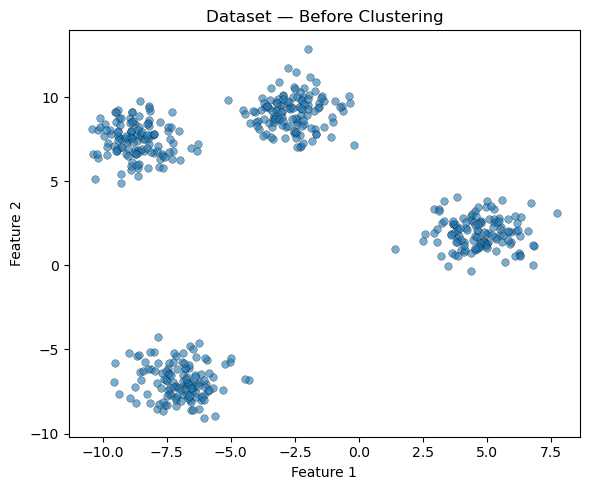

In [2]:
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

print('Shape:', X.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, edgecolors='k', linewidths=0.3, s=30)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset — Before Clustering')
plt.tight_layout()
plt.show()

---
## 3. Silhouette Score vs. k

In [3]:
k_values = range(2, 10)
silhouette_scores = []
wcss = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))
    wcss.append(km.inertia_)

best_k = k_values[np.argmax(silhouette_scores)]
print(f'Best k (max silhouette): {best_k}')
print(f'Best silhouette score  : {max(silhouette_scores):.4f}')

Best k (max silhouette): 4
Best silhouette score  : 0.7911


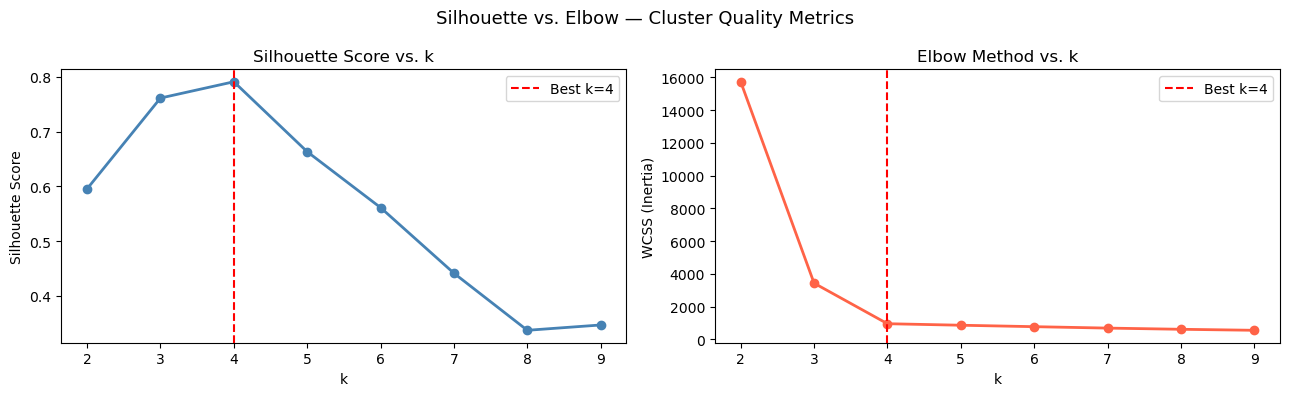

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Silhouette score
axes[0].plot(k_values, silhouette_scores, 'o-', lw=2, color='steelblue')
axes[0].axvline(x=best_k, color='red', linestyle='--', lw=1.5, label=f'Best k={best_k}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs. k')
axes[0].set_xticks(list(k_values))
axes[0].legend()

# Elbow (WCSS) for comparison
axes[1].plot(k_values, wcss, 'o-', lw=2, color='tomato')
axes[1].axvline(x=best_k, color='red', linestyle='--', lw=1.5, label=f'Best k={best_k}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('WCSS (Inertia)')
axes[1].set_title('Elbow Method vs. k')
axes[1].set_xticks(list(k_values))
axes[1].legend()

plt.suptitle('Silhouette vs. Elbow — Cluster Quality Metrics', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Fit K-Means with Best k and Visualize

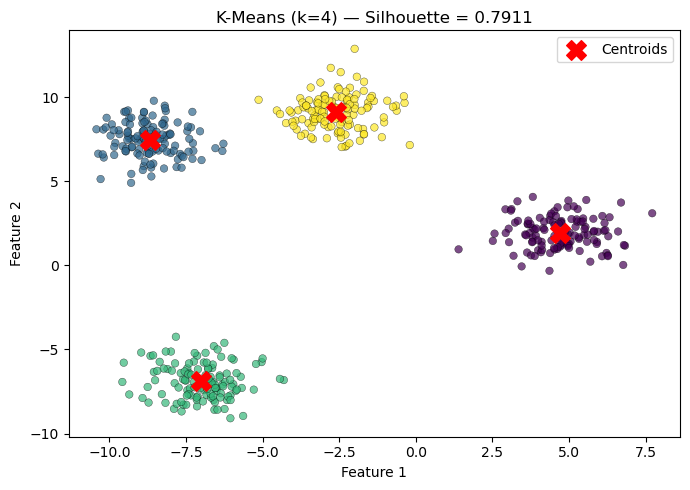

In [5]:
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km_best.fit_predict(X)
centroids = km_best.cluster_centers_

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis',
            alpha=0.7, edgecolors='k', linewidths=0.3, s=30)
plt.scatter(centroids[:, 0], centroids[:, 1],
            color='red', marker='X', s=200, zorder=5, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'K-Means (k={best_k}) — Silhouette = {max(silhouette_scores):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Per-Sample Silhouette Analysis

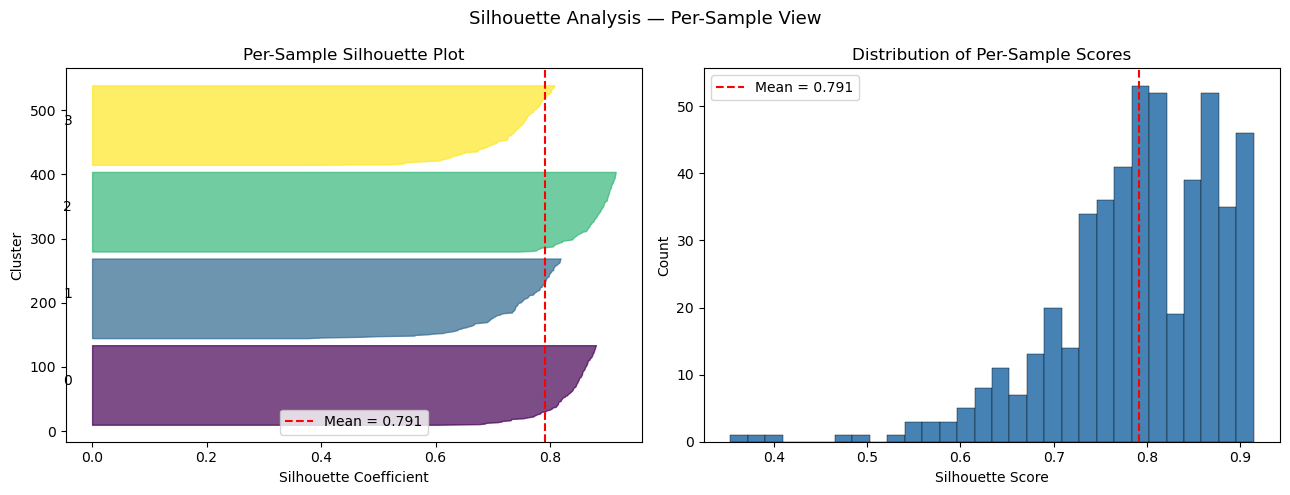

In [6]:
sample_scores = silhouette_samples(X, labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Silhouette plot per cluster
y_lower = 10
colors = plt.cm.viridis(np.linspace(0, 1, best_k))
for i in range(best_k):
    cluster_scores = np.sort(sample_scores[labels == i])
    size = cluster_scores.shape[0]
    y_upper = y_lower + size
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores,
                          facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    axes[0].text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

axes[0].axvline(x=max(silhouette_scores), color='red', linestyle='--',
                label=f'Mean = {max(silhouette_scores):.3f}')
axes[0].set_xlabel('Silhouette Coefficient')
axes[0].set_ylabel('Cluster')
axes[0].set_title('Per-Sample Silhouette Plot')
axes[0].legend()

# Score distribution
axes[1].hist(sample_scores, bins=30, color='steelblue', edgecolor='k', linewidth=0.3)
axes[1].axvline(x=max(silhouette_scores), color='red', linestyle='--',
                label=f'Mean = {max(silhouette_scores):.3f}')
axes[1].set_xlabel('Silhouette Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Per-Sample Scores')
axes[1].legend()

plt.suptitle('Silhouette Analysis — Per-Sample View', fontsize=13)
plt.tight_layout()
plt.show()

---
## Conclusion

- The **Silhouette Score** peaked at `k=4`, matching the true number of clusters in the `make_blobs` data — confirming it as a reliable metric for optimal `k`.
- Unlike WCSS (which always decreases), the silhouette score has a clear **maximum**, making the optimal `k` unambiguous even when the elbow is subtle.
- The **per-sample silhouette plot** shows that all clusters have scores well above 0, indicating tight, well-separated clusters with no significant misassignments.
- Use silhouette score alongside the elbow method — they are complementary: elbow shows cost reduction, silhouette shows cluster quality.